# Linear Algebra Practice

In [98]:
import numpy as np
import matplotlib.pyplot as plt

### Column space, null space, rank

In [99]:
def generate_rank_matrix(m, n, r, seed=None):
    rng = np.random.default_rng(seed)
    while True:
        U = rng.normal(size=(m, r)) * rng.integers(1, 4)
        V = rng.normal(size=(r, n)) * rng.integers(1,4)
        A = U @ V
        if np.linalg.matrix_rank(A) == r:
            return A
A = generate_rank_matrix(3,2,2)

In [100]:
def rref(A, tol=1e-12, ignore_last=False):
    pivots = []
    row = 0
    for c in range(len(A[0])):
        #check which column has the pivot
        if c == len(A[0])-1 and ignore_last:
            continue
        pivot = None
        for r in range(row, len(A)):
            if abs(A[r, c]) > tol:
                pivot = r
                break
        if pivot is None:
            continue
        if pivot != row:
            A[[r, pivot]] = A[[pivot, r]]
        A[r] = A[r] / A[r][c]
        for r in range(len(A)):
            if r != row:
                A[r] -= A[row] * A[r][c]
        pivots.append(row)
        row += 1
        if row == len(A[0]):
            break
    A[abs(A) < tol] = 0.0
    return A, pivots


R, pivots = rref(A.copy())                

In [101]:
def build_nullspace(R, pivots, tol=1e-12):
    R = R.astype(float)
    m, n = R.shape
    pivots = list(pivots)
    free_cols = [j for j in range(n) if j not in pivots]
    r = len(pivots)
    f = len(free_cols)

    if f == 0:
        return np.zeros((n, 0))  # empty basis

    N = np.zeros((n, f))
    for k, free_j in enumerate(free_cols):
        x = np.zeros(n)
        x[free_j] = 1.0
        for i, pivot_j in enumerate(pivots):
            x[pivot_j] = -R[i, free_j]
        N[:, k] = x

    N[np.abs(N) < tol] = 0.0
    return N


N = build_nullspace(A.copy(), pivots)
print(N)

[]


In [102]:
def column_basis(A, pivots):
    return A[:, pivots]
column_basis(A.copy(), pivots)

array([[ 2.82175183, -2.18402837],
       [ 0.08037524, -0.55051717],
       [-1.07075536,  0.60186335]])

In [103]:
def compute_solution(A, b, tol=1e-12):
    m, n = A.shape
    Aug = np.column_stack([A.astype(float), b.astype(float)])
    R_aug, pivots = rref(Aug, tol, True)  
    R = R_aug[:, :n]
    rhs = R_aug[:, n]

    for i in range(m):
        if np.all(np.abs(R[i]) < tol) and abs(rhs[i]) > tol:
            return np.zeros((n, 0)), "none"

    N = build_nullspace(R, pivots, tol)  
    x_p = np.zeros(n)
    for i, pcol in enumerate(pivots):
        if pcol < n:         
            x_p[pcol] = rhs[i]

    if N.shape[1] == 0:
        return x_p, "unique"
    else:
        full = np.column_stack([x_p, N])  
        return full, "infinite"
b = np.sum(column_basis(A.copy(), pivots), axis=1)
compute_solution(A.copy(), b)

(array([1., 1.]), 'unique')

### Projections

In [104]:
def compute_projections(a, b):
    numerator = np.dot(a.T, b)
    denominator = np.dot(a.T, a)
    x = numerator/denominator
    p = a * x
    return p
a = np.random.uniform(0, 10, size=3)
b = np.random.uniform(0, 10, size=3)
p = compute_projections(a,b)
ortho = np.dot((b-p), a)
print(p, ortho.round(10))

[2.64866004 7.04384916 0.93440045] 0.0


In [105]:
def compute_projection_matrix(A):
    _, pivots = rref(A.copy())
    A = A[:, pivots]
    inverse = np.linalg.inv(A.T @ A)
    P = A @ inverse @ A.T
    P[np.abs(P) < 1e-12] = 0.0
    return P

b = np.random.uniform(0, 10, size=A.shape[0])
P = compute_projection_matrix(A.copy())
projection = P @ b
print("Projection matrix P:")
print(P)
print("\nProjection of b onto column space of A:")
print(projection)
# Verify idempotent property of projection matrix
print("P @ P == P:", np.allclose(P @ P, P))

# Check orthogonality: A^T * (projection - b) should be zero
orthogonal_check = A.T @ (projection - b)
print("\nA^T * (projection - b):")
print(orthogonal_check)
print("Is orthogonal (close to zero):", np.allclose(orthogonal_check, 0))

Projection matrix P:
[[ 0.88744571  0.13318012 -0.28661625]
 [ 0.13318012  0.84241432  0.33913934]
 [-0.28661625  0.33913934  0.27013997]]

Projection of b onto column space of A:
[4.45029086 4.90298135 0.53060605]
P @ P == P: True

A^T * (projection - b):
[ 1.37112544e-14 -1.33226763e-14]
Is orthogonal (close to zero): True


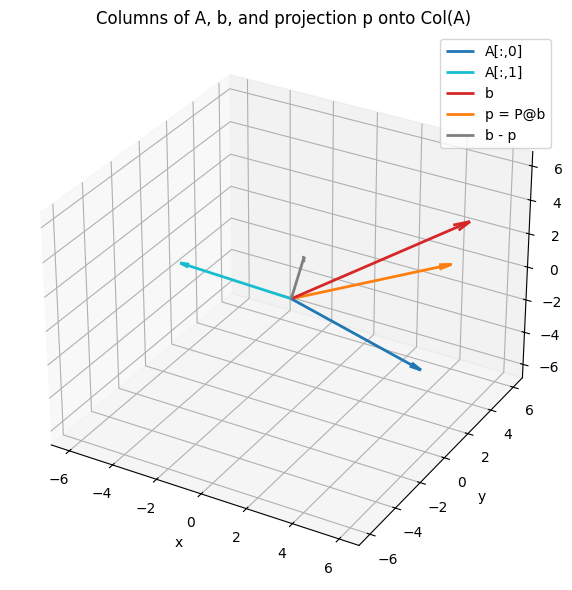

In [107]:

# Columns of A (each is a vector in R^3)
a_cols = [A[:, j] for j in range(A.shape[1])]

# b and its projection p onto Col(A)
p = projection  # or: p = P @ b

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

def draw_vec(v, color, label):
    ax.quiver(0, 0, 0, v[0], v[1], v[2],
              color=color, arrow_length_ratio=0.08, linewidth=2, label=label)

a_cols = [v * 2 for v in a_cols]
colors = ["tab:blue", "tab:cyan", "tab:purple", "tab:green"]
for j, v in enumerate(a_cols):
    draw_vec(v, colors[j % len(colors)], f"A[:,{j}]")

# draw b, projection p, and the residual (b - p)
draw_vec(b, "tab:red", "b")
draw_vec(p, "tab:orange", "p = P@b")
draw_vec(b - p, "tab:gray", "b - p")

# Set axis limits nicely
all_vecs = np.column_stack(a_cols + [b, p, b - p])
m = np.max(np.abs(all_vecs))
lim = 1.1 * (m if m > 0 else 1.0)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)

ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Columns of A, b, and projection p onto Col(A)")
ax.legend()
plt.tight_layout()
plt.show()

### Least Squares

In [132]:
def least_squares(A, b):
    b_hat = A.T @ b
    A_square = A.T @ A
    sol, status = compute_solution(A_square, b_hat)
    if status == "none":
        raise ValueError("Normal equations reported inconsistent (should not happen in exact arithmetic).")
    if status == "unique":
        x_hat = sol
    else: 
        x_hat = sol[:, 0] 
    return x_hat
# Generate a new overdetermined system for least squares (e.g., 4 equations, 2 variables)
new_A = generate_rank_matrix(4, 1, 1, seed=42)
new_A = np.column_stack([np.ones(4), new_A])
new_b = np.random.uniform(0, 10, size=4)

# Compute least squares solution
x_hat = least_squares(new_A, new_b)
print("Least squares solution x_hat:")
print(x_hat)
p = new_A @ x_hat
print(f"Projection of b on to Col(A): {p}")
e = new_b - p
ortho = new_A.T @ e
print("Ortho:", ortho)
print("Is ortho close to zero:", np.allclose(ortho, 0))

Least squares solution x_hat:
[ 5.39566168 -1.35377472]
Projection of b on to Col(A): [5.93283453 3.5623177  6.71860035 7.05374344]
Ortho: [ 1.33226763e-15 -1.88737914e-15]
Is ortho close to zero: True


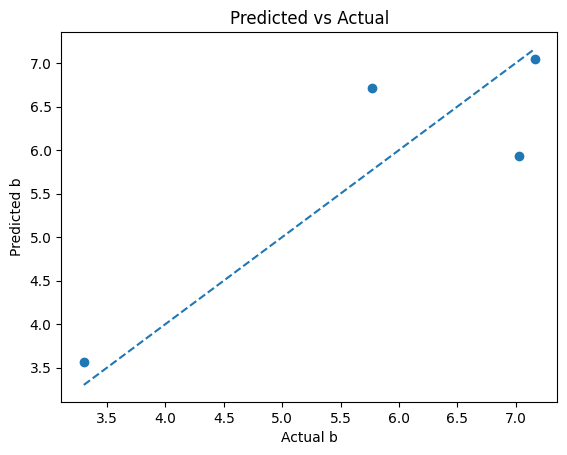

In [133]:
b_pred = new_A @ x_hat
plt.scatter(new_b, b_pred)
plt.xlabel("Actual b")
plt.ylabel("Predicted b")
plt.title("Predicted vs Actual")
plt.plot([new_b.min(), new_b.max()], [new_b.min(), new_b.max()], '--')  # y=x reference
plt.show()